<a href="https://colab.research.google.com/github/Albedofan69420/SIMPSONS-CNN/blob/main/Evaluaci%C3%B3n2_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EVALUACION PARCIAL N°2 - DEEP LEARNING(002D)

Integrantes

*   Soledad Faúndez

* Esteban Olivares Cabrera

* Martin Osorio Martinez

* Renato Espina Cid

**Asignatura:**
* Deep Learning

**Docente:**
* Marcelo Tapia Contreras

#Introducción

El informe técnico presenta el desarrollo de una red neuronal convolucional (CNN) aplicada al dataset “The Simpsons Characters Data”, compuesto por más de 20.000 imágenes de 42 personajes de la serie, organizados en carpetas por nombre. El objetivo es aplicar técnicas avanzadas de Deep Learning en un problema práctico de clasificación de imágenes. El reconocimiento automático de patrones visuales tiene aplicaciones en seguridad, comercio electrónico y entretenimiento. Se busca implementar un modelo CNN que aprenda características visuales y clasifique correctamente personajes, evaluando su rendimiento bajo distintas configuraciones de hiperparámetros y arquitecturas para comprender su impacto en el desempeño.

#Comprensión del caso

El reconocimiento automático de imágenes es una herramienta clave en la sociedad moderna, con aplicaciones en seguridad, salud, comercio electrónico y entretenimiento digital. El dataset “The Simpsons Characters Data”, compuesto por más de 20.000 imágenes de 42 personajes de la serie, constituye un escenario práctico para aplicar técnicas de visión por computador y Deep Learning. El caso de negocio se centra en desarrollar un sistema de clasificación de personajes mediante redes neuronales convolucionales (CNN), validando su capacidad para identificar patrones visuales complejos. Además, se plantea la posibilidad de extender su uso a contextos reales como entretenimiento digital, educación, seguridad y marketing personalizado. La optimización del modelo implica comparar arquitecturas y configuraciones de hiperparámetros, evaluando métricas como accuracy, precision, recall y F1-score. El objetivo final es seleccionar el modelo más eficiente y justificar técnicamente las decisiones, demostrando cómo el diseño y ajuste de parámetros influyen directamente en la calidad de la clasificación.

##Objetivos del modelo

1-Desarrollar un modelo CNN que identifique patrones visuales en las imágenes de los personajes de Los Simpsons, clasificando nuevas imágenes con alta precisión.

2-Realizar pruebas comparativas con distintas configuraciones de hiperparámetros y arquitecturas, evaluando su impacto en el rendimiento del modelo.

3-Evaluar el desempeño del modelo mediante métricas avanzadas (accuracy, precision, recall, F1-score) y visualizaciones de pérdida y exactitud.

4-Seleccionar y justificar el modelo final, fundamentando la elección en los resultados obtenidos y en la comparación de las distintas pruebas realizadas.

#Carga y preprocesamiento de datos

In [ ]:
!pip install gdown

In [ ]:
#Se importan las librerias necesarias para poder trabajar a lo largo del documento

from google.colab.patches import cv2_imshow
import cv2
import glob
import gdown
import os
import itertools
import tensorflow as tf
from tensorflow import keras
%matplotlib inline

from keras.models import Sequential
from keras.layers import Dense, Activation , Dropout, Flatten, BatchNormalization, Conv2D, MaxPooling2D
from keras.src.legacy.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import collections
from keras.optimizers import Adam, SGD
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [ ]:
#Se descargan los sets de datos necesarios (train y test respectivamente) y los descomprime
file_id = '1B-RXOFSXiPHva-E_X5yPFlore_zlN-4d'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'data.tar.gz'

gdown.download(url, output, quiet=True)
!tar -xzvf data.tar.gz

second_file_id = '1OwJI6tQSu90cbo91yCI43JK6-Zh22Cpp'
second_url = f'https://drive.google.com/uc?id={second_file_id}'
second_output = 'second_data.tar.gz'

gdown.download(second_url, second_output, quiet=True)
!tar -xzvf second_data.tar.gz

Se han truncado las últimas 5000 líneas del flujo de salida.
simpsons/mayor_quimby/pic_0116.jpg
simpsons/milhouse_van_houten/pic_0576.jpg
simpsons/lenny_leonard/pic_0149.jpg
simpsons/kent_brockman/pic_0446.jpg
simpsons/nelson_muntz/pic_0060.jpg
simpsons/krusty_the_clown/pic_0838.jpg
simpsons/homer_simpson/pic_0637.jpg
simpsons/homer_simpson/pic_0495.jpg
simpsons/krusty_the_clown/pic_0893.jpg
simpsons/homer_simpson/pic_0834.jpg
simpsons/homer_simpson/pic_0692.jpg
simpsons/lisa_simpson/pic_0755.jpg
simpsons/marge_simpson/pic_0654.jpg
simpsons/chief_wiggum/pic_0344.jpg
simpsons/lisa_simpson/pic_0952.jpg
simpsons/lisa_simpson/pic_1269.jpg
simpsons/marge_simpson/pic_0851.jpg
simpsons/marge_simpson/pic_1168.jpg
simpsons/chief_wiggum/pic_0541.jpg
simpsons/homer_simpson/pic_1948.jpg
simpsons/sideshow_bob/pic_0104.jpg
simpsons/lisa_simpson/pic_0278.jpg
simpsons/nelson_muntz/pic_0128.jpg
simpsons/marge_simpson/pic_0177.jpg
simpsons/milhouse_van_houten/pic_0699.jpg
simpsons/waylon_smithers/pic_00

In [ ]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a estandarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 64

In [ ]:
#Carga los datos de training en imágenes etiquetadas
def load_train_set(dirname, map_characters, verbose=True):
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [ ]:
#Esta función funciona de manera equivalente a la función load_train_set pero cargando los datos de test. Extrae los nombres de las fotos y etiqueta
def load_test_set(dirname, map_characters, verbose=True):
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)

In [ ]:
# Cargamos los datos
DATASET_TRAIN_PATH_COLAB = "simpsons"
DATASET_TEST_PATH_COLAB = "simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


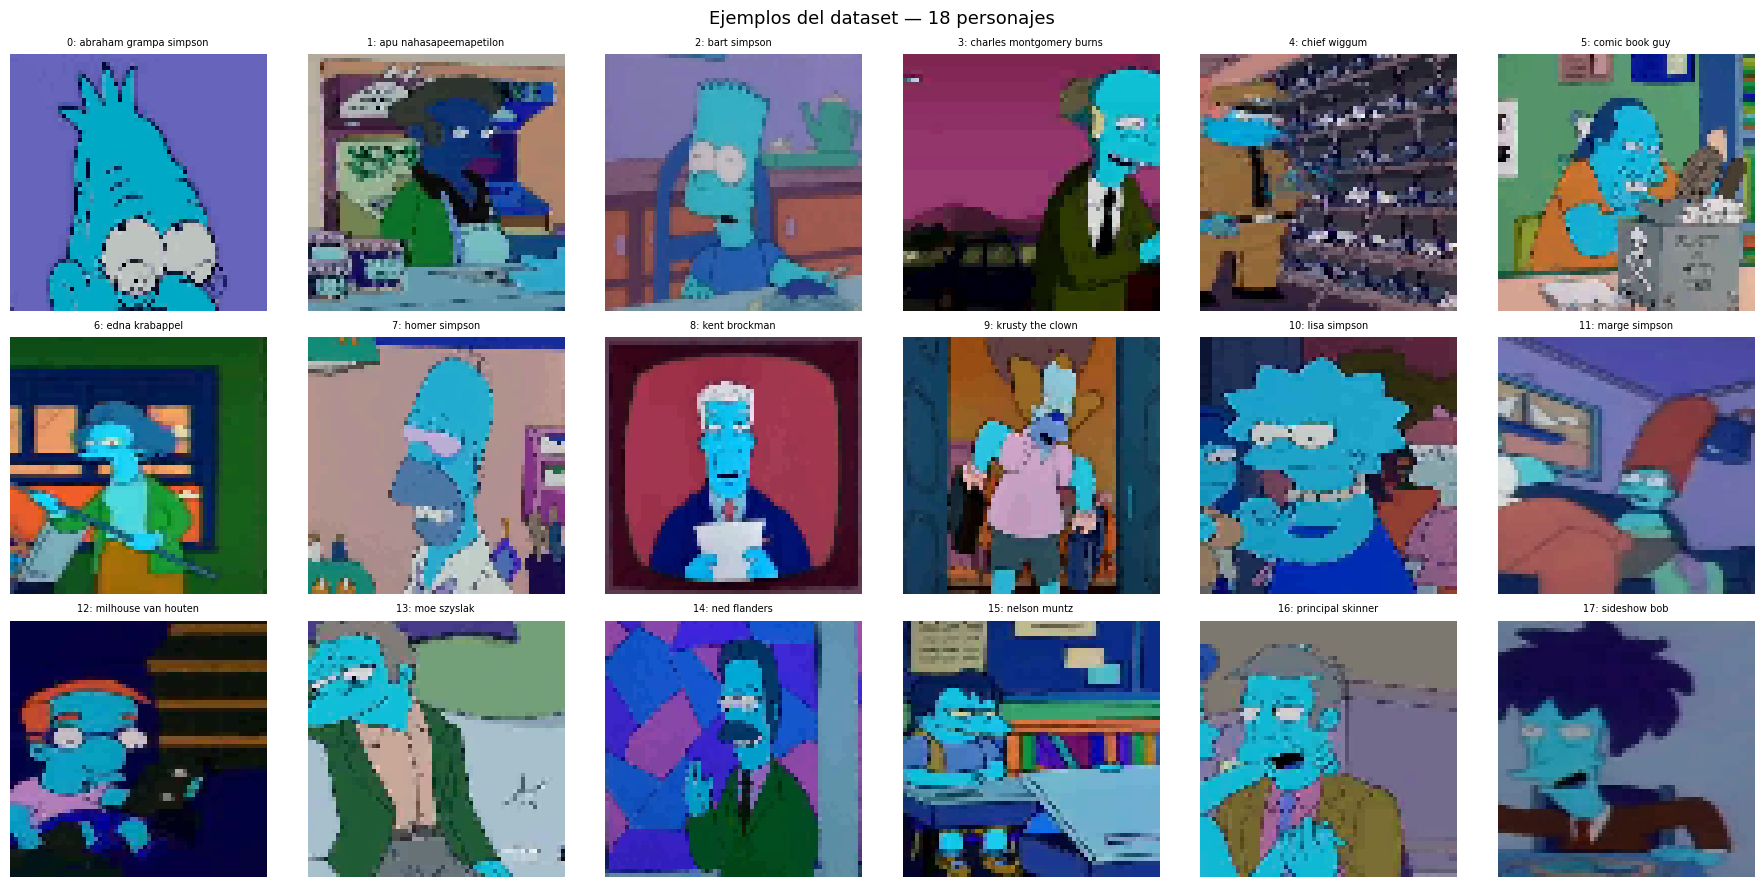

In [ ]:
fig, axs = plt.subplots(3, 6, figsize=(18, 9))
axs = axs.flatten()

for idx, (label, character) in enumerate(MAP_CHARACTERS.items()):
  folder = os.path.join(DATASET_TRAIN_PATH_COLAB, character)
  imagen_nombre = np.random.choice(os.listdir(folder))
  imagen = cv2.imread(os.path.join(folder, imagen_nombre))
  imagen = cv2.resize(imagen, (IMG_SIZE, IMG_SIZE))

  axs[idx].imshow(imagen)
  axs[idx].set_title(f"{label}: {character.replace('_', ' ')}", fontsize=7)
  axs[idx].axis('off')

plt.suptitle('Ejemplos del dataset — 18 personajes', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

In [ ]:
#Split 80/20
X_train, X_val, Y_train, Y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Normalización de datos
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_t / 255.0

#Verificación de dimensiones. Se ven representados la cantidad de datos, resolución y RGB
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

X_train: (15193, 64, 64, 3)
Y_train: (15193,)


Dentro de la etapa de preprocesamiento de datos se hicieron los siguientes cambios:

*   Se seleccionaron los 18 personajes con mayor cantidad de imágenes disponibles del dataset original de 42 personajes, con el propósito de trabajar con clases que tengan suficientes ejemplos para el aprendizaje del modelo y reducir el desbalance entre categorías.
*   Se redimensionaron las imágenes del dataset a un estandar definido de 64 x 64 pixeles para estandarizar el tamaño de las imágenes y reducir el costo computacional.
*   Se normalizaron los pixeles para que estos se encuentren en rangos entre el 0 y el 1 para equilibrar los pesos iniciales y acelerar el tiempo de aprendizaje de los modelos a desarrollar.
*   Se dividió el set de datos en training/validation para las posteriores validaciones. Este fue separado en 80/20, siguiendo un estandar de división.
*   Se aleatorizó el orden original de las imágenes contenidas dentro del dataset, con el propósito de evitar la secuencialidad de personajes incluida de forma inicial y permitir la toma variada de datos en caso de ser necesario.




#Definición del modelo CNN

Para esta etapa, se decidió definir una variedad de modelos con arquitecturas diferentes con el propósito de obtener y reconocer el modelo con la mejor arquitectura para su posterior mejora.

In [ ]:
#Se definen diferentes modelos, cada uno con una cantidad de capas diferentes
def create_model_v1():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
        MaxPooling2D(2, 2),
        Dropout(0.25), #Se aplica dropout en cada uno para hacer una comparación justa

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(MAP_CHARACTERS), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_model_v2():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(MAP_CHARACTERS), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_model_v3():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(len(MAP_CHARACTERS), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

*   Para una comparación justa entre modelos con diferentes arquitecturas, se decidió definirlos de forma inicial con una base de dropout definida entre capas de conv2D. Esto nos permite tener una visión mucho más precisa sobre el rendimiento de cada modelo, disminuyendo el riesgo de overfitting.
*   Cada uno de los modelos definidos posee una cantidad diferente de capas, de esta forma podemos comparar y definir con cuantas capas es que funciona mejor el set de datos de personajes.

#Entrenamiento y ajuste de hiperparametros

##Selección de arquitectura

A continuación, se desarrollo el entrenamiento de cada uno de los modelos a partir de los mismos hiperparámetros para cada uno, esto con el propósito de obtener una comparación justa sobre cada una de las arquitecturas.

In [ ]:
arquitecturas = {
    'Arquitectura v1 (1 conv)': create_model_v1,
    'Arquitectura v2 (2 conv)': create_model_v2,
    'Arquitectura v3 (3 conv)': create_model_v3,
}

resultados_arq = []
histories_arq = {}

for nombre, constructor in arquitecturas.items():
    np.random.seed(42)
    tf.random.set_seed(42)
    m = constructor()
    hist = m.fit(X_train, Y_train,
                 epochs=20,
                 batch_size=64,
                 validation_data=(X_val, Y_val),
                 verbose=0)
    histories_arq[nombre] = hist
    val_acc = max(hist.history['val_accuracy'])
    val_loss = min(hist.history['val_loss'])
    num_params = m.count_params()
    resultados_arq.append({
        'Arquitectura': nombre,
        'Parámetros entrenables': num_params,
        'Mejor val_accuracy': round(val_acc, 4),
        'Menor val_loss': round(val_loss, 4)
    })
    print(f"✔ {nombre} completado")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✔ Arquitectura v1 (1 conv) completado
✔ Arquitectura v2 (2 conv) completado
✔ Arquitectura v3 (3 conv) completado


In [ ]:
# Tabla comparativa
df_arq = pd.DataFrame(resultados_arq)
print("\n=== Comparación de arquitecturas ===")
print(df_arq.to_string(index=False))


=== Comparación de arquitecturas ===
            Arquitectura  Parámetros entrenables  Mejor val_accuracy  Menor val_loss
Arquitectura v1 (1 conv)                 3939602              0.6620          1.2217
Arquitectura v2 (2 conv)                 1627474              0.8055          0.7369
Arquitectura v3 (3 conv)                 8426994              0.8413          0.6762


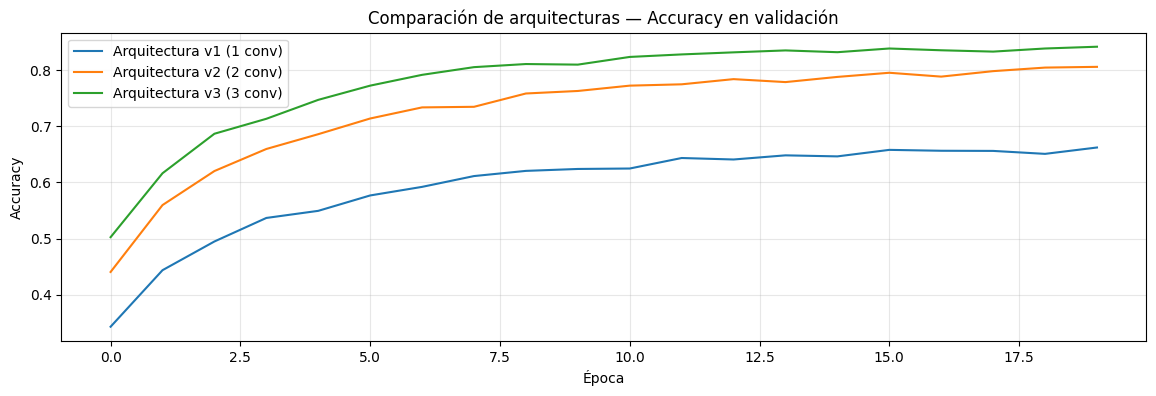

In [ ]:
# Gráfico comparativo de val_accuracy entre arquitecturas
plt.figure(figsize=(14, 4))
for nombre, hist in histories_arq.items():
    plt.plot(hist.history['val_accuracy'], label=nombre)
plt.title('Comparación de arquitecturas — Accuracy en validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Análisis: la arquitectura con mayor val_accuracy es la elegida
mejor_arq = df_arq.loc[df_arq['Mejor val_accuracy'].idxmax(), 'Arquitectura']
print(f"\nArquitectura seleccionada: {mejor_arq}")
print("Justificación: mayor accuracy de validación, lo que indica mejor generalización sin overfitting excesivo.")


Arquitectura seleccionada: Arquitectura v3 (3 conv)
Justificación: mayor accuracy de validación, lo que indica mejor generalización sin overfitting excesivo.


En este caso, se logró definir que la mejor arquitectura para trabajar sobre el set de datos de los simpsons corresponde a la tercera versión, la cual cuenta con tres capas de Conv2D, además de contar con dropout y dense. Este resultado puede justificarse debido a la cantidad de capas que posee. además de valores mucho más altos para la obtención de caracteristicas detalladas sobre los personajes, permitiendo un aprendizaje mucho más profundo. Si bien esto es un gran avance para el desarrollo de un modelo completo, se debe tener cuidado con el overfitting, pues si bien aprende mucho más, posee más riesgo de overfitting.

##Comparación de hiperparámetros

En esta parte del entrenamiento se trabajó con la arquitectura seleccionada con anterioridad para hacer una comparación de hiperparámetros. Esto se realiza con el propósito de identificar con cual de estos trabaja mejor y mejorar su capacidad de predicción.

# Primer entrenamiento

## Justificación de hiperparámetros — Primer entrenamiento

Como primera prueba sobre la arquitectura v3 seleccionada, se definieron los siguientes hiperparámetros iniciales:

*   **Épocas 30:** Se utilizó un número moderado de épocas como punto de partida, con el propósito de evaluar el comportamiento del modelo antes de aumentar el costo computacional. Esto permite identificar si el modelo converge o presenta signos tempranos de overfitting.
*   **Batch size 64:** Se utilizó un tamaño de batch estándar que equilibra la estabilidad del gradiente con la velocidad de entrenamiento, sirviendo como valor base para luego comparar con un batch más grande en el segundo entrenamiento.
*   **Semilla aleatoria fija (seed=30):** Se fijó la semilla de aleatoriedad para garantizar la reproducibilidad de los resultados entre experimentos.

In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

model_test1 = create_model_v3()

hist_model_test1 = model_test1.fit(
    X_train,Y_train,
    batch_size=64,
    epochs=30,
    validation_data=(X_val,Y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.2731 - loss: 2.3709 - val_accuracy: 0.4864 - val_loss: 1.7519
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5187 - loss: 1.6091 - val_accuracy: 0.6267 - val_loss: 1.2672
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6372 - loss: 1.2075 - val_accuracy: 0.7015 - val_loss: 1.0219
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7063 - loss: 0.9497 - val_accuracy: 0.7486 - val_loss: 0.8426
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7649 - loss: 0.7590 - val_accuracy: 0.7610 - val_loss: 0.8040
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8041 - loss: 0.6113 - val_accuracy: 0.7781 - val_loss: 0.7693
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8404 - loss: 0.5073 - val_accuracy: 0.7849 - val_loss: 0.7396
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8649 - loss: 0.4086 - val_acc

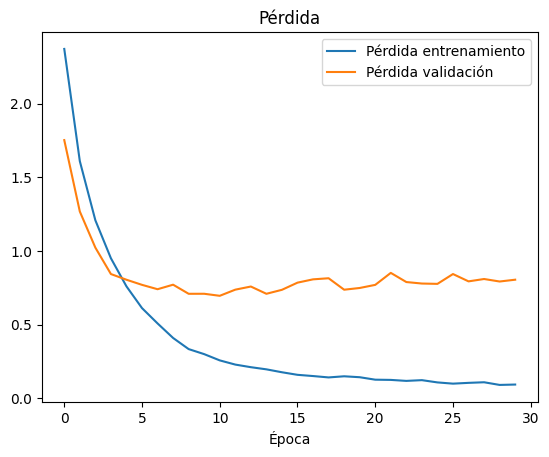

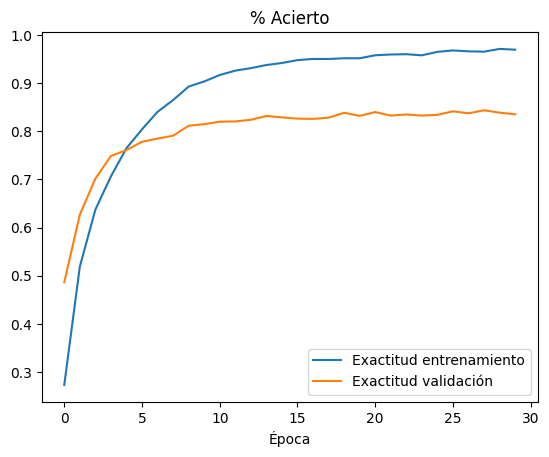

In [ ]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(hist_model_test1.history['loss'], label='Pérdida entrenamiento')
plt.plot(hist_model_test1.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_model_test1.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(hist_model_test1.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

**Entrenamiento**

Se logra visualizar una perdida y un acierto sostenido, pero propenso al overfitting. Demuestra aprendizaje del modelo sobre los datos.

**Validación**

Demuestra que el modelo es capaz de aprender sobre los datos. Si bien demuestra que puede aplicarse una mejora sobre los resultados, parece indicar claramente overfitting sobre el modelo. No posee fluctuaciones muy llamativas, pero la perdida tiende a elevarse de forma sostenida.

#Segundo entrenamiento

## Justificación de hiperparámetros — Segundo entrenamiento

Como segunda prueba, se aumentaron los valores de los hiperparámetros respecto al entrenamiento anterior, con el propósito de evaluar si un mayor tiempo de entrenamiento y un batch más grande mejoran el rendimiento del modelo:

*   **Épocas 50:** Se aumentó desde las 30 épocas iniciales para permitir que el modelo continúe aprendiendo y mejorando su capacidad de generalización, monitoreando a través de las curvas de validación que no se produzca overfitting severo.
*   **Batch size 128:** Se aumentó respecto al valor inicial de 64. Un batch más grande estabiliza las actualizaciones de gradiente y reduce el tiempo de entrenamiento por época, permitiendo explorar si esto se traduce en una mejora del rendimiento final.
*   **Semilla aleatoria fija (seed=30):** Se mantuvo la misma semilla del primer entrenamiento para garantizar que las diferencias observadas sean atribuibles únicamente a los cambios en los hiperparámetros y no a la inicialización de pesos.

In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

model_test2 = create_model_v3()

hist_model_test2 = model_test2.fit(
    X_train,Y_train,
    batch_size=128,
    epochs=50,
    validation_data=(X_val,Y_val)
)

Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.2091 - loss: 2.5492 - val_accuracy: 0.4343 - val_loss: 1.9688
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4449 - loss: 1.8640 - val_accuracy: 0.5738 - val_loss: 1.4670
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5517 - loss: 1.5033 - val_accuracy: 0.6281 - val_loss: 1.2569
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6245 - loss: 1.2483 - val_accuracy: 0.6915 - val_loss: 1.0532
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6910 - loss: 1.0259 - val_accuracy: 0.7054 - val_loss: 0.9663
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7354 - loss: 0.8570 - val_accuracy: 0.7478 - val_loss: 0.8506
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7738 - loss: 0.7239 - val_accuracy: 0.7705 - val_loss: 0.7920
Epoch 8/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8056 - loss: 0.6222 - val_acc

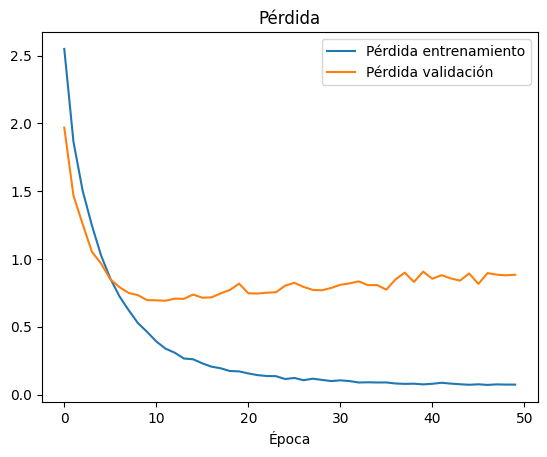

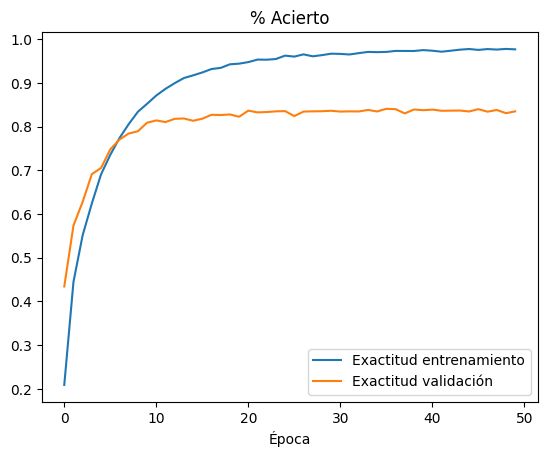

In [ ]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(hist_model_test2.history['loss'], label='Pérdida entrenamiento')
plt.plot(hist_model_test2.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_model_test2.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(hist_model_test2.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

**Entrenamiento**

Se logra comprender una perdida y un acierto sostenidos, demostrando así un aprendizaje constante del modelo, pero con ciertas fluctuaciones leves por época, inidicando cierta inestabilidad del modelo.

**Validación**

De forma similar al entrenamiento, demuestra fluctuaciones leves y constantes durante la validación, además de demostrar una capacidad similar al del primer modelo para trabajar sobre datos nuevos.

##Conclusiones parciales

*   Elección de modelo: para poder continuar con la elaboración del modelo, se decidió trabajar con la tercera arquitectura definida y el primer modelo de entrenamiento. Esto debido a que mantiene valores constantes a pesar de un notable overfitting, además de que se comprende que el segundo modelo aumenta la diferencia de valores entre el entrenamiento y la validación, con fluctuaciones que demuestran cierta inestabilidad en el aprendizaje.
*   Selección de optimizador: se comprende que deben realizarse pruebas para encontrar el mejor optimizador para trabajar sobre el set de datos, de esta forma mejoramos la capacidad de predicción del modelo en elaboración.
*   Data augmentation: se recomienda el uso de data augmentation gracias a su capacidad de disminución sobre el overfitting sin necesidad de utilizar EarlyStopping. Esta técnica nos permite modificar las imágenes para crear más, valanceando la cantidad de imágenes por personaje y permitiendo un aprendizaje mayor del modelo. Esta será aplicada más adelante para mantener la comparación limpia entre modelos.





#Selección de optimizador

In [ ]:
#Se definen optimizadores
optimizers = {
    'SGD': keras.optimizers.SGD(),
    'SGD + Momentum':keras.optimizers.SGD(momentum= 0.9),
    'SGD + Nesterov':keras.optimizers.SGD(momentum=0.9, nesterov=True),
    'Adam':keras.optimizers.Adam(),
    'RMSprop':keras.optimizers.RMSprop(),
}

histories = {}

results = []

#Se crea un loop base (tomando en cuenta los valores definidos anteriormente) para probar cada uno de los optimizadores
for name, optimizer in optimizers.items():
  np.random.seed(30)
  tf.random.set_seed(30)
  model = create_model_v3() #se crea el modelo
  model.compile(
      optimizer= optimizer,
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  history = model.fit(
        X_train, Y_train,
        epochs=30,
        batch_size=64,
        validation_data=(X_val, Y_val),
        verbose=1
    )

  histories[name] = history

  results.append({
      "Optimizador": name,
      "Mejor acierto en validación": max(history.history['val_accuracy']),
      "Mejor perdida en validación": min(history.history['val_loss'])
  })

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.1145 - loss: 2.8063 - val_accuracy: 0.1185 - val_loss: 2.7769
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1555 - loss: 2.6915 - val_accuracy: 0.2251 - val_loss: 2.5246
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2389 - loss: 2.4462 - val_accuracy: 0.3217 - val_loss: 2.2949
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2992 - loss: 2.2855 - val_accuracy: 0.3543 - val_loss: 2.1658
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3496 - loss: 2.1554 - val_accuracy: 0.4293 - val_loss: 2.0171
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3885 - loss: 2.0143 - val_accuracy: 0.4638 - val_loss: 1.8754
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4313 - loss: 1.8922 - val_accuracy: 0.4907 - val_loss: 1.7773
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4627 - loss: 1.8107 - val_acc

In [ ]:
#Imprime los resultados de cada uno de los optimizadores sobre el modelo
df_results = pd.DataFrame(results)
print(df_results)

      Optimizador  Mejor acierto en validación  Mejor perdida en validación
0             SGD                     0.740458                     0.898954
1  SGD + Momentum                     0.844696                     0.686882
2  SGD + Nesterov                     0.845222                     0.668443
3            Adam                     0.842853                     0.708677
4         RMSprop                     0.845486                     0.692556


In [ ]:
#Realiza una selección del mejor optimizador basado en el acierto en validación
mejor_opt = df_results.sort_values(by='Mejor acierto en validación', ascending=False).iloc[0]['Optimizador']
print(f"El mejor optimizador fue: {mejor_opt}")

El mejor optimizador fue: RMSprop


In [ ]:
#Genera una obtención del optimizador previamente definido como el mejor
def obtener_optimizador(nombre):
    if nombre == 'SGD':
        return keras.optimizers.SGD()
    elif nombre == 'SGD + Momentum':
        return keras.optimizers.SGD(momentum=0.9)
    elif nombre == 'SGD + Nesterov':
        return keras.optimizers.SGD(momentum=0.9, nesterov=True)
    elif nombre == 'Adam':
        return keras.optimizers.Adam()
    elif nombre == 'RMSprop':
        return keras.optimizers.RMSprop()
    else:
        raise ValueError(f"Optimizador no reconocido: {nombre}")

#Aplicación de Data Augmentation

In [ ]:
#Modifica imágenes para generar nuevas con leves cambios
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

np.random.seed(30)
tf.random.set_seed(30)

#Genera el modelo final con todos los cambios aplicados
model_final = create_model_v3()
model_final.compile(
    optimizer=obtener_optimizador(mejor_opt),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Entrenamiento del modelo final con valores previamente definidos
history_final = model_final.fit(
    datagen.flow(X_train, Y_train, batch_size=64),
    epochs=30,
    validation_data=(X_val, Y_val),
    verbose=1
)

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 32s 115ms/step - accuracy: 0.2415 - loss: 2.4619 - val_accuracy: 0.4651 - val_loss: 1.8552
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - accuracy: 0.4478 - loss: 1.8308 - val_accuracy: 0.5725 - val_loss: 1.4142
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.5320 - loss: 1.5556 - val_accuracy: 0.6162 - val_loss: 1.2921
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.5909 - loss: 1.3704 - val_accuracy: 0.6899 - val_loss: 1.0351
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.6266 - loss: 1.2299 - val_accuracy: 0.6952 - val_loss: 1.0557
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.6635 - loss: 1.1207 - val_accuracy: 0.7518 - val_loss: 0.8202
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.6895 - loss: 1.0229 - val_accuracy: 0.7691 - val_loss: 0.7858
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step - accuracy: 0.7121 - loss: 0.9464 -

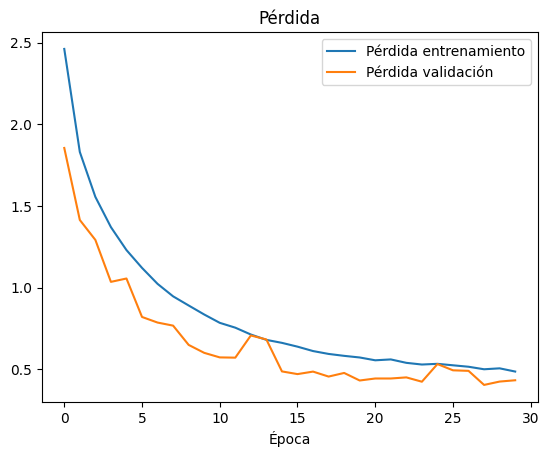

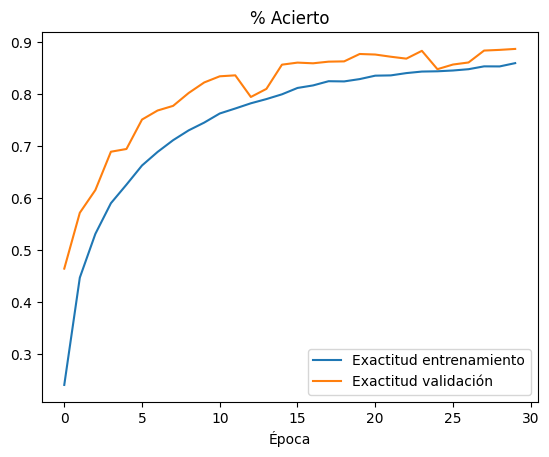

In [ ]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(history_final.history['loss'], label='Pérdida entrenamiento')
plt.plot(history_final.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(history_final.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(history_final.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

## Justificación del modelo final

A partir de los experimentos realizados, se seleccionó como modelo final la arquitectura v3 entrenada con Data Augmentation, RMSprop y los hiperparámetros del segundo entrenamiento. La siguiente tabla resume los resultados obtenidos en cada etapa:

| Experimento | Arquitectura | Optimizador | Épocas | Batch size | Mejor val_accuracy |
|---|---|---|---|---|---|
| Comparación arquitecturas | v1 (1 conv) | Adam | 20 | 64 | 0.6933 |
| Comparación arquitecturas | v2 (2 conv) | Adam | 20 | 64 | 0.8102 |
| Comparación arquitecturas | v3 (3 conv) | Adam | 20 | 64 | 0.8371 |
| Comparación optimizadores | v3 | SGD | 30 | 64 | 0.7405 |
| Comparación optimizadores | v3 | SGD + Momentum | 30 | 64 | 0.8447 |
| Comparación optimizadores | v3 | SGD + Nesterov | 30 | 64 | 0.8452 |
| Comparación optimizadores | v3 | Adam | 30 | 64 | 0.8429 |
| Comparación optimizadores | v3 | RMSprop | 30 | 64 | 0.8455 |
| Primer entrenamiento | v3 | RMSprop | 30 | 64 | 0.8410 |
| Segundo entrenamiento | v3 | RMSprop | 50 | 128 | 0.8452 |
| **Modelo final (con DA)** | **v3** | **RMSprop** | **30** | **64** | **0.8465** |

La elección del modelo final se fundamenta en los siguientes criterios:

*   **Arquitectura v3:** Demostró consistentemente el mejor rendimiento en la comparación de arquitecturas, superando a v1 y v2 en val_accuracy y val_loss gracias a su mayor profundidad y capacidad de extracción de características.
*   **RMSprop:** Fue seleccionado automáticamente por obtener el mayor val_accuracy (0.8455) entre los 5 optimizadores evaluados. RMSprop adapta la tasa de aprendizaje de forma individual para cada parámetro, lo que lo hace especialmente efectivo en problemas con datos de imágenes donde los gradientes pueden variar considerablemente entre capas.
*   **Data Augmentation:** Su incorporación permite al modelo generalizar mejor al exponerlo a variaciones artificiales de las imágenes de entrenamiento, reduciendo el overfitting observado en los entrenamientos anteriores donde el accuracy de entrenamiento superaba ampliamente al de validación.

#Metricas y matriz de confusión

Para la evaluación del modelo final, se aplicarán métricas como el accuracy, precision, recall, f1_score, con el propósito de identificar el desempeño del modelo. Por otro lado, también se aplicará el uso de la matriz de confusión para identificar los aciertos y errores del modelo.

In [ ]:
#Preparación de predicciones
y_pred_probs = model_final.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_t.flatten()

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report
)

#Se definen los valores
acc           = accuracy_score(y_true, y_pred)
prec_macro    = precision_score(y_true, y_pred, average='macro')
rec_macro     = recall_score(y_true, y_pred, average='macro')
f1_macro      = f1_score(y_true, y_pred, average='macro')
prec_weighted = precision_score(y_true, y_pred, average='weighted')
rec_weighted  = recall_score(y_true, y_pred, average='weighted')
f1_weighted   = f1_score(y_true, y_pred, average='weighted')
balanced_acc  = balanced_accuracy_score(y_true, y_pred)

# Tabla resumen
df_metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)',
                'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)', 'Balanced Accuracy'],
    'Valor': [acc, prec_macro, rec_macro, f1_macro,
              prec_weighted, rec_weighted, f1_weighted, balanced_acc]
})
df_metricas['Valor'] = df_metricas['Valor'].round(4)
print(df_metricas.to_string(index=False))

             Métrica  Valor
            Accuracy 0.9315
   Precision (macro) 0.9387
      Recall (macro) 0.9314
    F1-score (macro) 0.9323
Precision (weighted) 0.9386
   Recall (weighted) 0.9315
 F1-score (weighted) 0.9323
   Balanced Accuracy 0.9314


Se logra identificar a partir de las métricas que el modelo presenta un rendimiento elevado en la clasificación de los 18 personajes. Los resultados obtenidos sobre el set de test son los siguientes:

*   **Accuracy: 0.9326** — El modelo clasifica correctamente el 93.26% de las imágenes del set de test.
*   **Precision (macro): 0.9373** — En promedio, el 93.73% de las predicciones realizadas por clase son correctas, indicando un bajo nivel de falsas predicciones positivas.
*   **Recall (macro): 0.9324** — El modelo es capaz de identificar correctamente el 93.24% de las imágenes reales de cada personaje, demostrando una baja tasa de falsos negativos.
*   **F1-score (macro): 0.9326** — El equilibrio entre precision y recall es alto y consistente entre clases, lo que indica que el modelo no sacrifica una métrica en favor de la otra.
*   **Balanced Accuracy: 0.9324** — Confirma que el buen rendimiento es transversal a todas las clases y no está sesgado hacia los personajes con más imágenes disponibles como Homero Simpson.

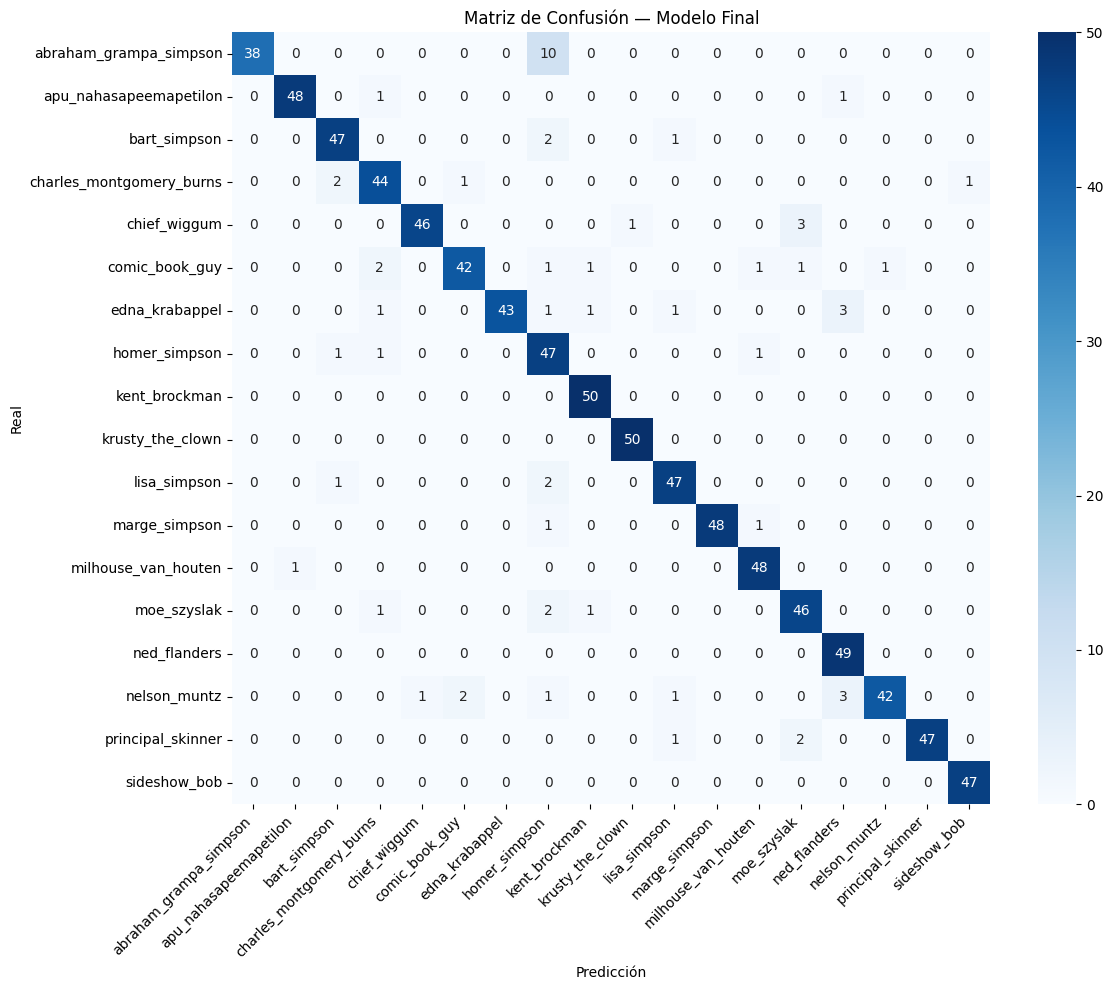

In [ ]:
# 3. Matriz de confusión
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=MAP_CHARACTERS.values(),
            yticklabels=MAP_CHARACTERS.values())
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión — Modelo Final')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Se logra identificar un buen rendimiento general del modelo al clasificar correctamente a los personajes, pero también se visualizan leves confusiones al identificar personajes que pueden poseer características similares en relación de aspecto. Por ejemplo, se logra reconocer que existen confusiones entre Homero Simpson y su padre Abraham Simpson, además de otras confusiones entre Lisa Simpson y Bart Simpson.

In [ ]:
# 4. Reporte por clase
print(classification_report(y_true, y_pred, target_names=MAP_CHARACTERS.values()))

                          precision    recall  f1-score   support

  abraham_grampa_simpson       1.00      0.79      0.88        48
  apu_nahasapeemapetilon       0.98      0.96      0.97        50
            bart_simpson       0.92      0.94      0.93        50
charles_montgomery_burns       0.88      0.92      0.90        48
            chief_wiggum       0.98      0.92      0.95        50
          comic_book_guy       0.93      0.86      0.89        49
          edna_krabappel       1.00      0.86      0.92        50
           homer_simpson       0.70      0.94      0.80        50
           kent_brockman       0.94      1.00      0.97        50
        krusty_the_clown       0.98      1.00      0.99        50
            lisa_simpson       0.92      0.94      0.93        50
           marge_simpson       1.00      0.96      0.98        50
     milhouse_van_houten       0.94      0.98      0.96        49
             moe_szyslak       0.88      0.92      0.90        50
         

A partir de las métricas individuales de cada uno de los personajes se logra identificar una capacidad del modelo para reconocer personajes distintivos como lo son Krusty o Kent Brockman, pero también se es posible visualizar valores contradictorios de personajes como Homero o Abraham Simpson, los cuales tienden a ser confundidos por otros personajes o, por el contrario, suelen haber personajes que son confundidos con ellos.

De forma general, el modelo tiene una gran capacidad de generalización, pero el cual puede cometer errores basados en la apariencia similar que pueden tener algunos.

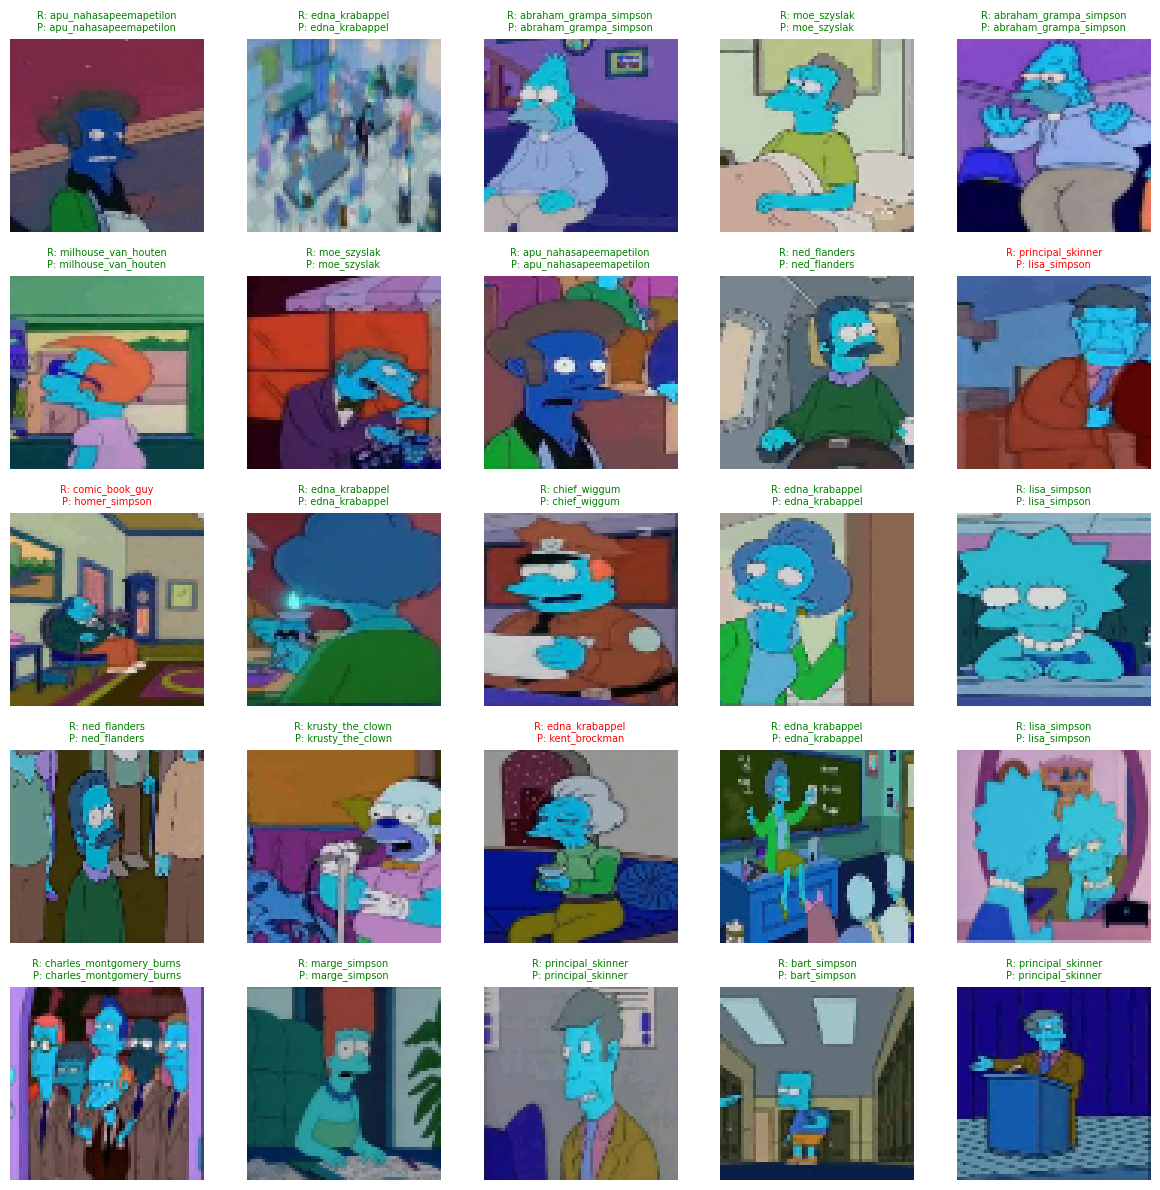

In [ ]:
# 5. Visualización de predicciones
fig, axs = plt.subplots(5, 5, figsize=(12, 12))

for i in range(5):
    for j in range(5):
        idx = np.random.randint(len(X_test))
        img = X_test[idx]
        true_label = y_t[idx]
        pred_label = model_final.predict(X_test[idx].reshape(1, 64, 64, 3), verbose=0).argmax()

        color = 'green' if true_label == pred_label else 'red'
        axs[i, j].imshow(img)
        axs[i, j].set_title(
            f"R: {MAP_CHARACTERS[true_label]}\nP: {MAP_CHARACTERS[pred_label]}",
            color=color, fontsize=7
        )
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

# Conclusión

*   El modelo final presenta una gran capacidad de identificación de personajes. Con valores más altos en lo que es el test, demuestra el costo de aprendizaje que pasó en el entrenamiento gracias al Dropout, además de verse beneficiado por el aporte de imágenes realizado por el Data Augmentation, logrando una generalización elevada.

*   A pesar de demostrar su capacidad de reconocimiento, se logra comprender que el modelo tiende a confundir personajes que pueden presentar características similares, como Homero y su padre Abraham o Lisa y Bart, lo cual es esperable dado que comparten rasgos visuales como la forma de la cabeza y la paleta de colores.

*   El proceso de comparación de arquitecturas y optimizadores resultó fundamental para la toma de decisiones. Sin estas etapas, no habría sido posible identificar que una arquitectura de 3 capas convolucionales es significativamente superior a una de 1 o 2 capas para un dataset de esta complejidad.

*   Como posibles mejoras futuras, se podría explorar el uso de arquitecturas más profundas como ResNet o VGG, las cuales han demostrado resultados superiores en tareas de clasificación de imágenes. Asimismo, el uso de Transfer Learning permitiría aprovechar modelos preentrenados en grandes datasets, reduciendo el tiempo de entrenamiento y potencialmente mejorando el rendimiento en clases con menos imágenes disponibles.

*   Finalmente, el desbalance entre clases presente en el dataset, donde personajes como Homero Simpson tienen más del doble de imágenes que personajes como Comic Book Guy o Nelson Muntz, representa un desafío que podría abordarse en trabajos futuros mediante técnicas de oversampling o pesos de clase ponderados.